# Penyusunan Model

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
import joblib, pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, classification_report

## 1. Pre-processing model -- Pembersihan data

In [3]:
df = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\UsHER\AppData\Local\Temp\ipykernel_15592\325939391.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('D:\dummyML\data\polder_data_fix.csv')


,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


In [4]:
df.describe

<bound method NDFrame.describe of                  timestamp  Debit_Cipalasari  Debit_Hilir  Debit_Hulu Pump1  \
0      2025-06-09 00:00:00          0.466032     2.389919    1.819317    on   
1      2025-06-09 00:02:27          0.470409     2.398388    1.836405    on   
2      2025-06-09 00:07:27          0.479342     2.415673    1.871278    on   
3      2025-06-09 00:12:27          0.488275     2.432957    1.906150    on   
4      2025-06-09 00:17:27          0.497208     2.450241    1.941023    on   
...                    ...               ...          ...         ...   ...   
30647  2025-06-11 22:12:27          0.000000     7.724410    0.134400    on   
30648  2025-06-11 22:17:27          0.000000     7.724410    0.134400    on   
30649  2025-06-11 22:22:27          0.000000     7.724410    0.134400    on   
30650  2025-06-11 22:27:27          0.000000     7.724410    0.134400    on   
30651  2025-06-11 23:00:00          0.000000     7.724410    0.134400    on   

      Pump2 Pump3

In [5]:
#Drop kolom timestamp
df.drop('timestamp', axis=1, inplace=True)
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


In [6]:
# Feature engineering (Merge Pump1, Pump2, and Pump3 into a single column)
df['pump'] = df[['Pump1', 'Pump2', 'Pump3']].eq('on').sum(axis=1)
df.drop(columns=['Pump1', 'Pump2', 'Pump3'], inplace=True)
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0,2


In [7]:
#Drop kolom bojongsoang, dayeuhkolot, pintu pump_on, dan status banjir
df.drop(columns=['bojongsoang', 'dayeuhkolot', 'pintu', 'pump_on', 'status_banjir'], inplace=True)
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,2


## 2. Preprocessing model -- Transformasi data

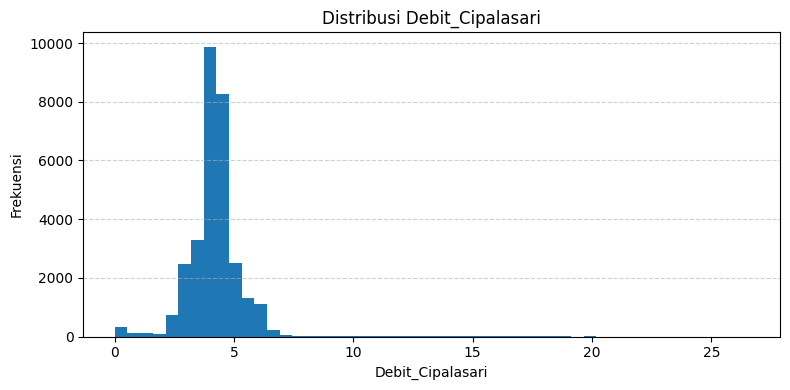

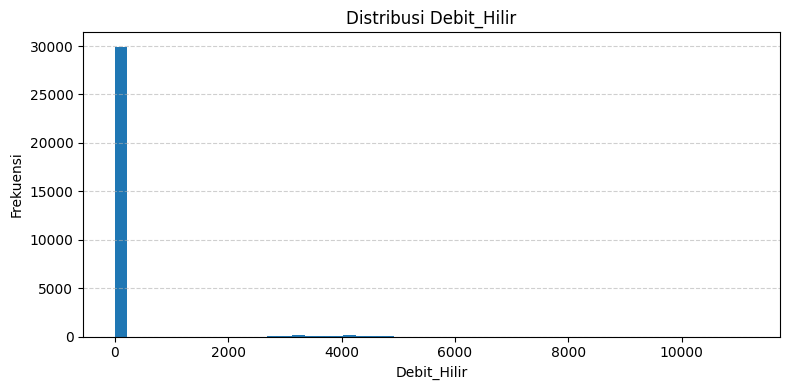

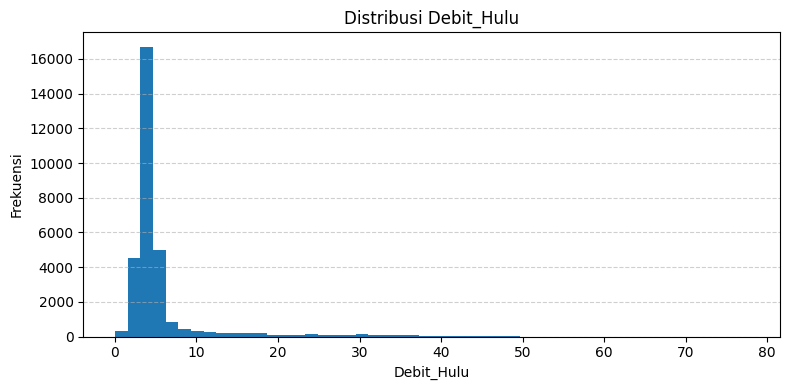

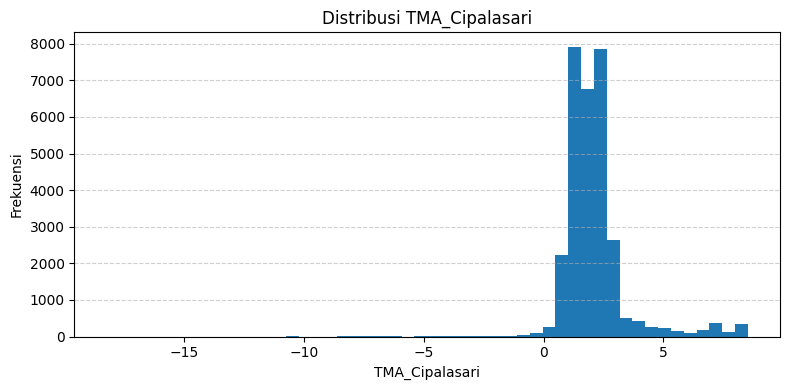

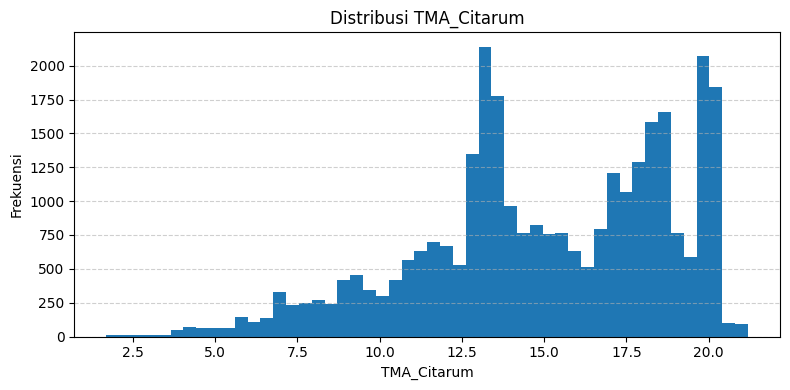

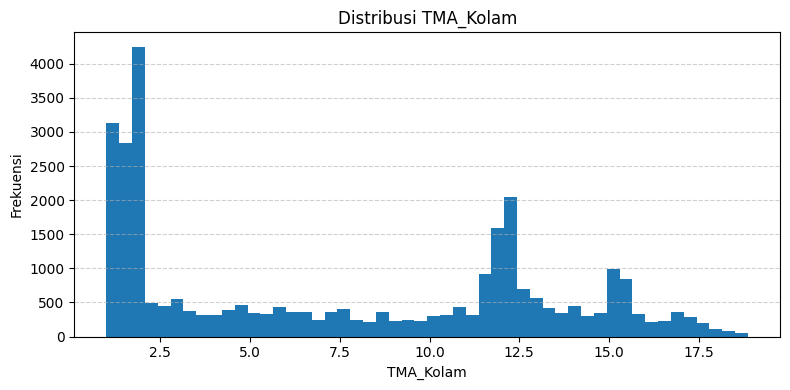

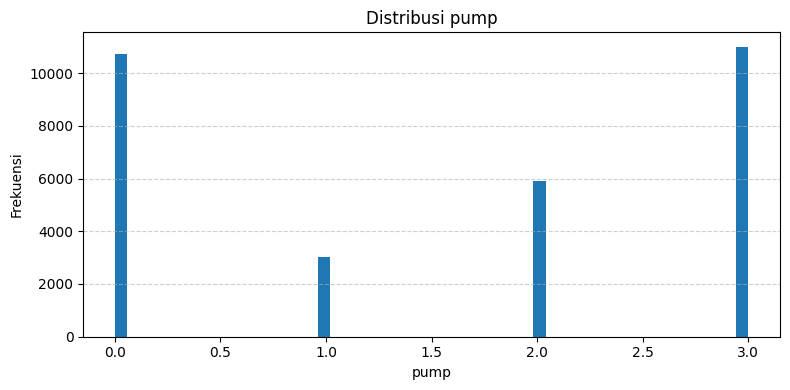

In [8]:
# Analisa distribusi data
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

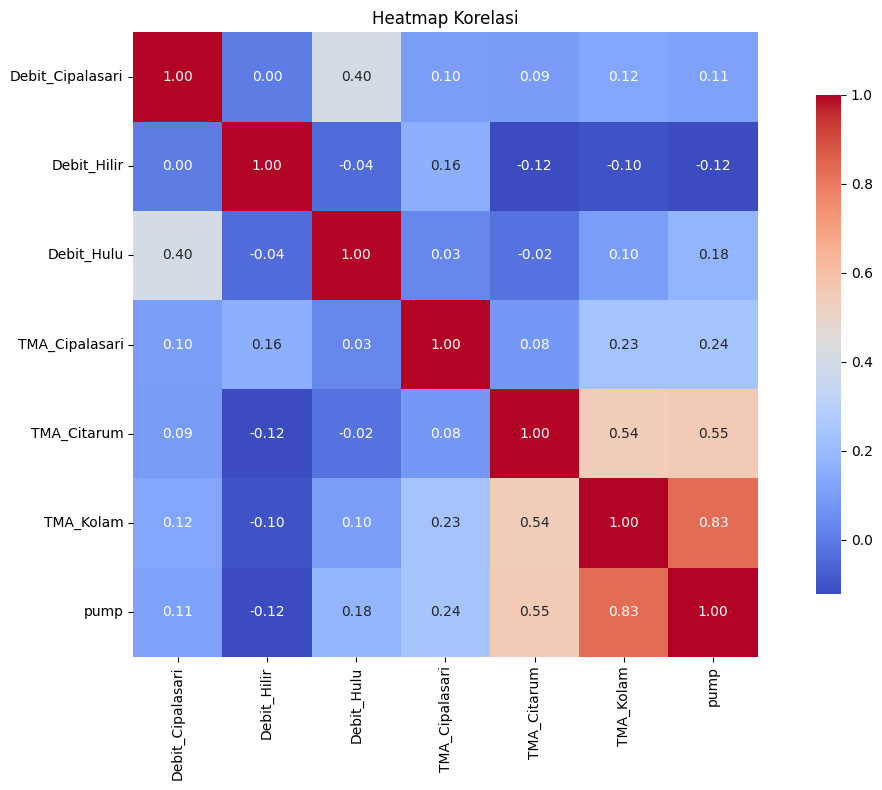

In [9]:
#lihat heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

In [10]:
# 1. Debit_cipalasari

# Transformasi Logaritmik
df['Debit_Cipalasari_log'] = np.log1p(df['Debit_Cipalasari'])

# Transformasi Winsorization
df['Debit_Cipalasari_winsorized'] = stats.mstats.winsorize(df['Debit_Cipalasari'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['Debit_Cipalasari_norm'] = robust_scaler.fit_transform(df[['Debit_Cipalasari']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['Debit_Cipalasari_quantile'] = quantile_transformer.fit_transform(df[['Debit_Cipalasari']])


               variabel  skewness          stat  p_value           test
0  Debit_Cipalasari_log -2.325098  17743.332857      0.0  D’Agostino K²
                      variabel  skewness          stat       p_value  \
0         Debit_Cipalasari_log -2.325098  17743.332857  0.000000e+00   
1  Debit_Cipalasari_winsorized  0.202597    208.717279  4.760128e-46   

            test  
0  D’Agostino K²  
1  D’Agostino K²  
                      variabel  skewness          stat       p_value  \
0         Debit_Cipalasari_log -2.325098  17743.332857  0.000000e+00   
1  Debit_Cipalasari_winsorized  0.202597    208.717279  4.760128e-46   
2        Debit_Cipalasari_norm  4.244257  29049.995442  0.000000e+00   

            test  
0  D’Agostino K²  
1  D’Agostino K²  
2  D’Agostino K²  
                      variabel  skewness          stat       p_value  \
0         Debit_Cipalasari_log -2.325098  17743.332857  0.000000e+00   
1  Debit_Cipalasari_winsorized  0.202597    208.717279  4.760128e-46   
2

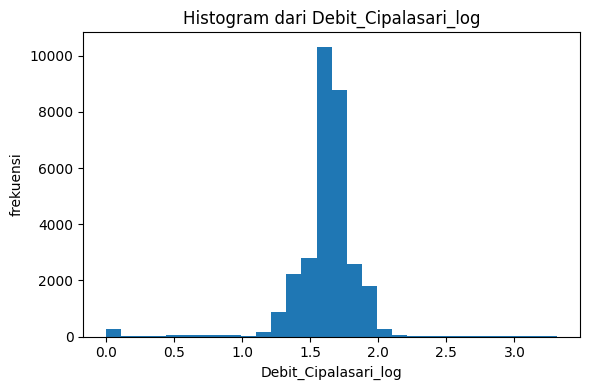

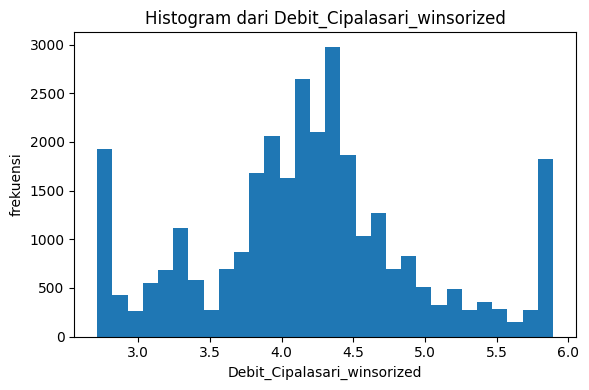

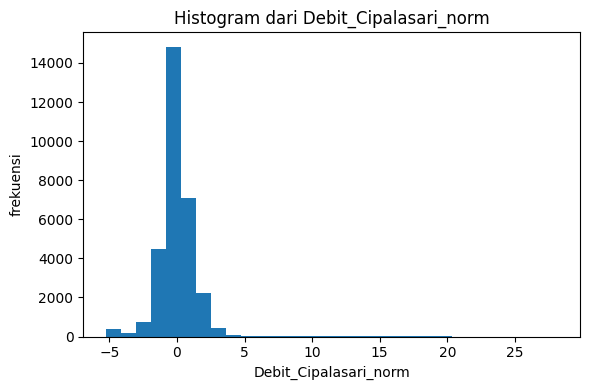

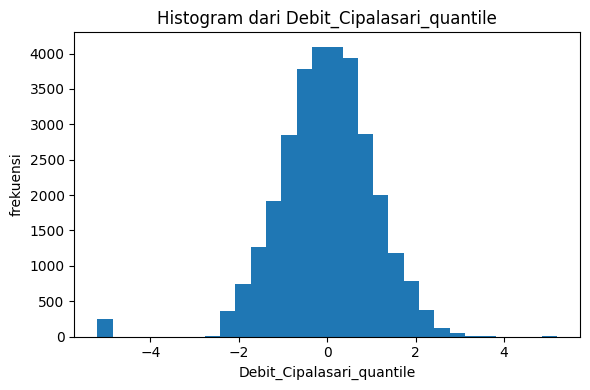

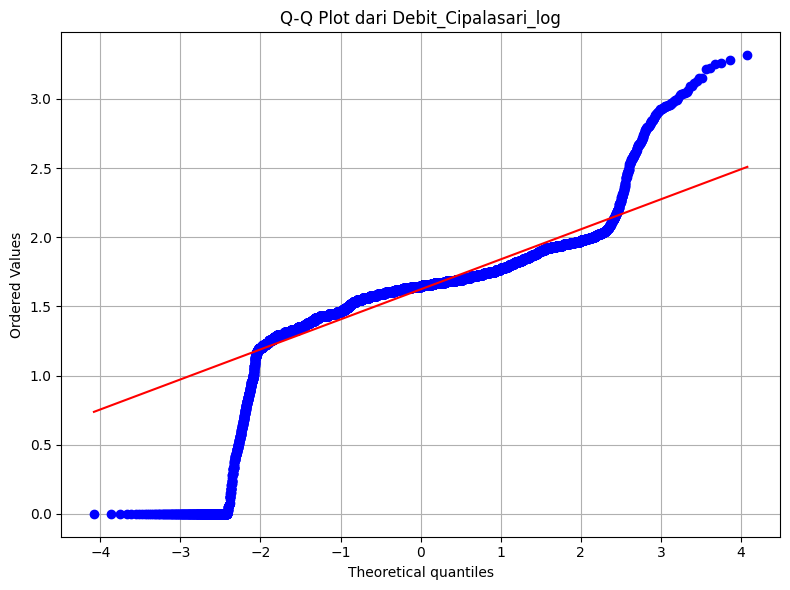

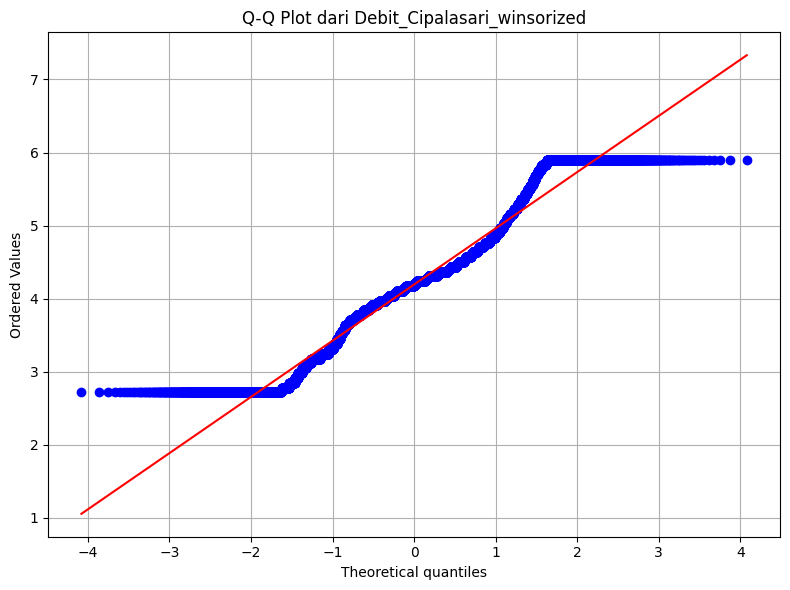

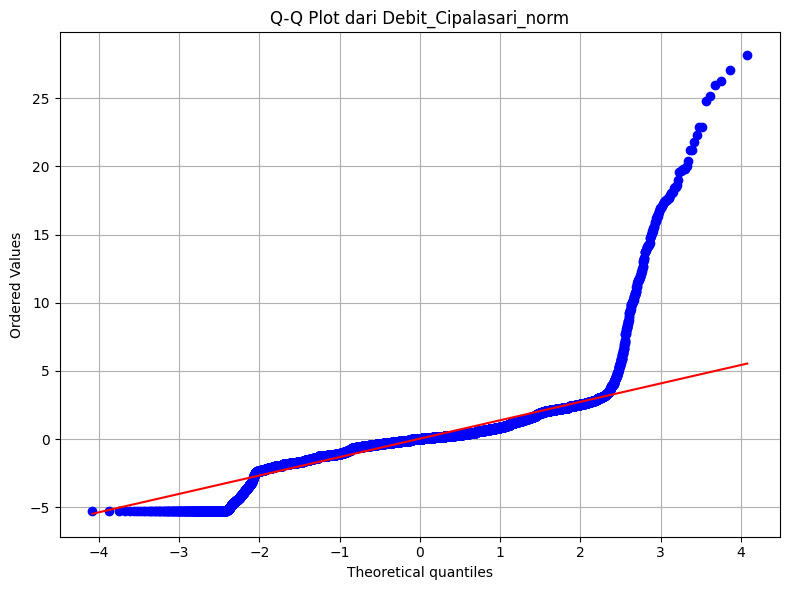

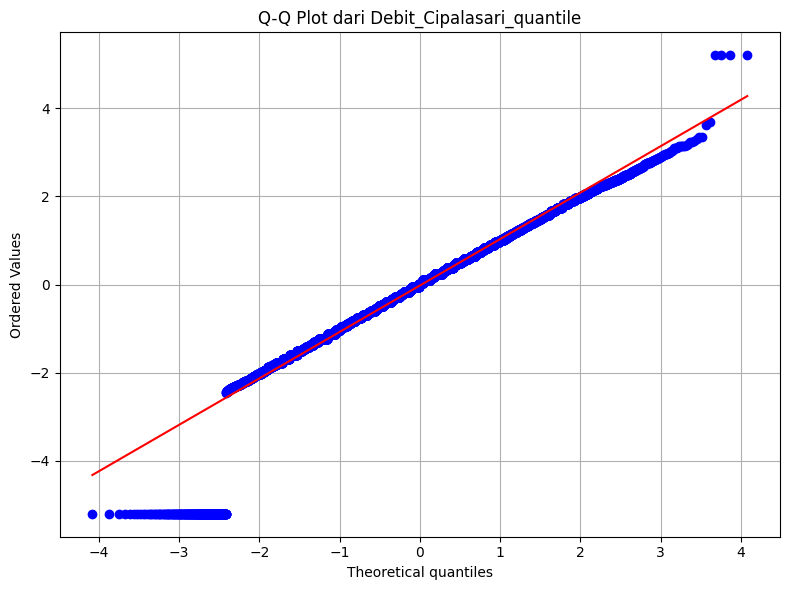

In [11]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 1. Debit_cipalasari

var = 'Debit_Cipalasari'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [12]:
# 2. Debit_Hulu

# Transformasi Logaritmik
df['Debit_Hulu_log'] = np.log1p(df['Debit_Hulu'])

# Transformasi Winsorization
df['Debit_Cipalasari_winsorized'] = stats.mstats.winsorize(df['Debit_Cipalasari'], limits=[0.05, 0.05])
df['Debit_Hulu_winsorized'] = stats.mstats.winsorize(df['Debit_Hulu'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['Debit_Hulu_norm'] = robust_scaler.fit_transform(df[['Debit_Hulu']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['Debit_Hulu_quantile'] = quantile_transformer.fit_transform(df[['Debit_Hulu']])


         variabel  skewness          stat  p_value           test
0  Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
                variabel  skewness          stat  p_value           test
0         Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
1  Debit_Hulu_winsorized  2.684753  16332.543557      0.0  D’Agostino K²
                variabel  skewness          stat  p_value           test
0         Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
1  Debit_Hulu_winsorized  2.684753  16332.543557      0.0  D’Agostino K²
2        Debit_Hulu_norm  3.919454  24524.609208      0.0  D’Agostino K²
                variabel  skewness          stat  p_value           test
0         Debit_Hulu_log  1.742888  11273.934108      0.0  D’Agostino K²
1  Debit_Hulu_winsorized  2.684753  16332.543557      0.0  D’Agostino K²
2        Debit_Hulu_norm  3.919454  24524.609208      0.0  D’Agostino K²
3    Debit_Hulu_quantile -0.643614   3882.749640      0.0  D’Agos

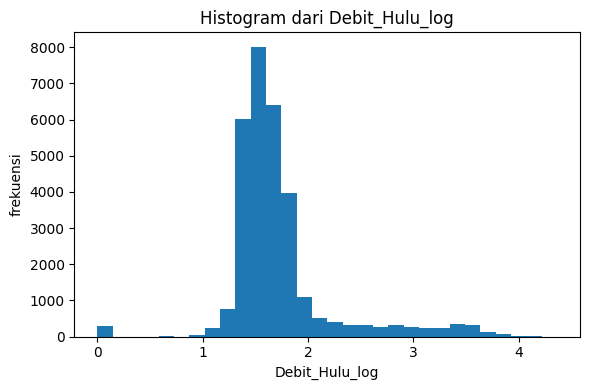

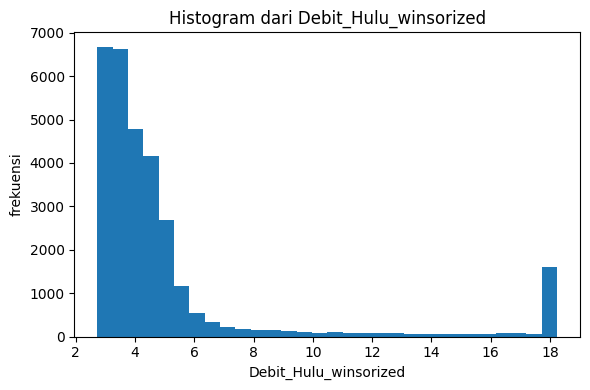

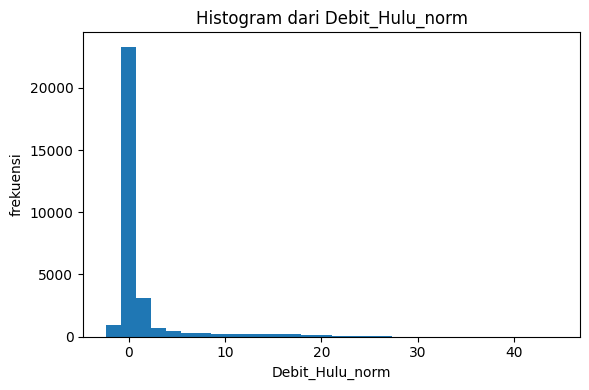

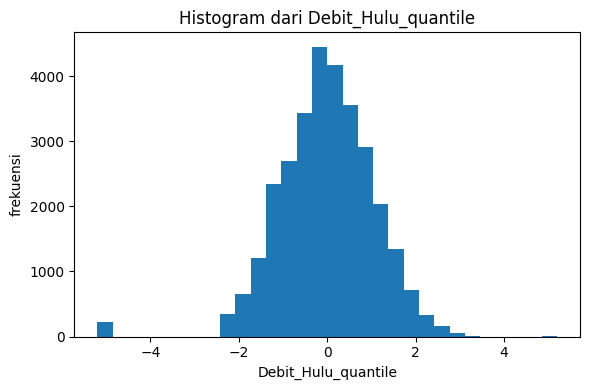

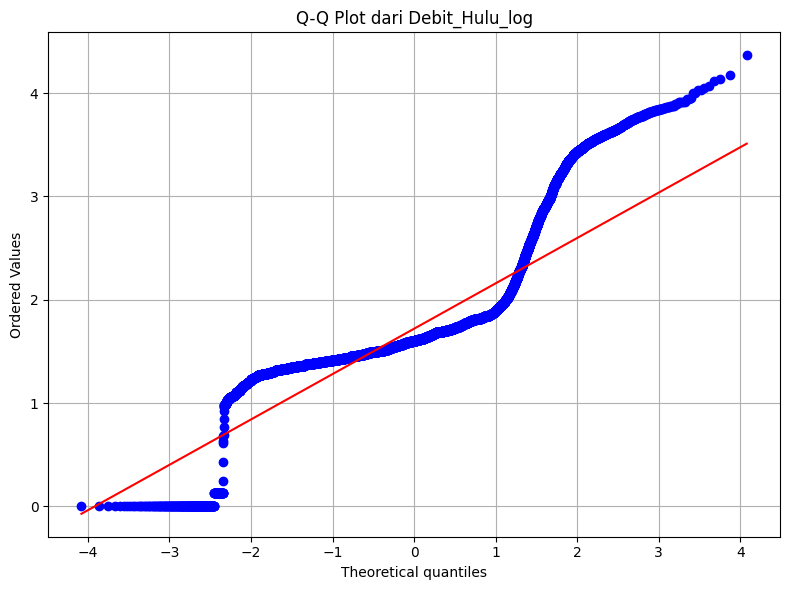

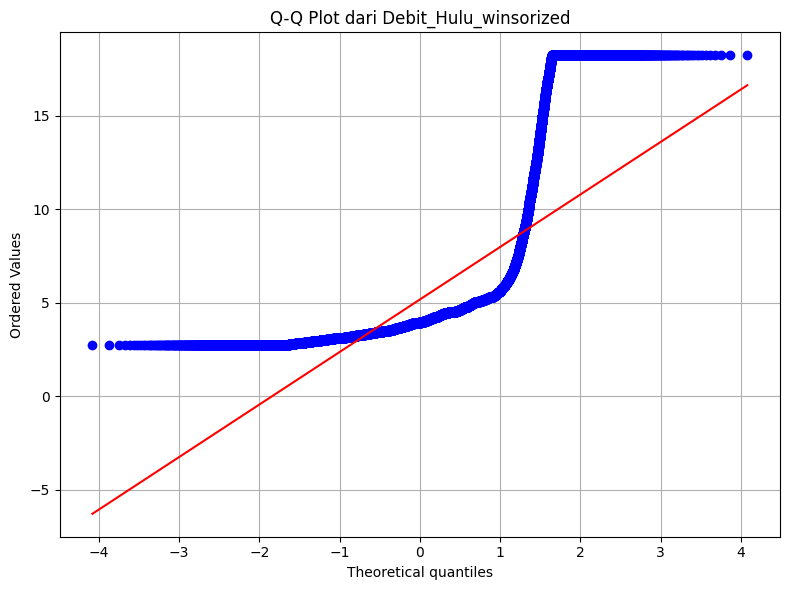

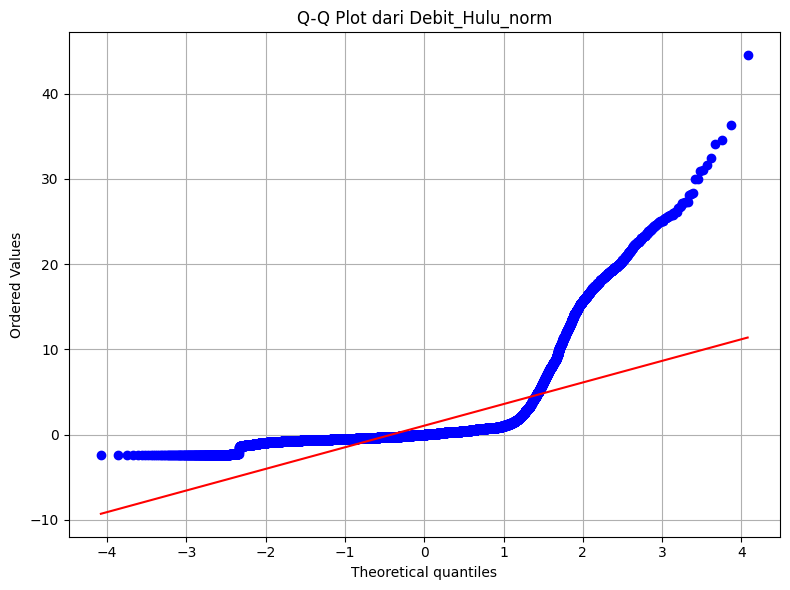

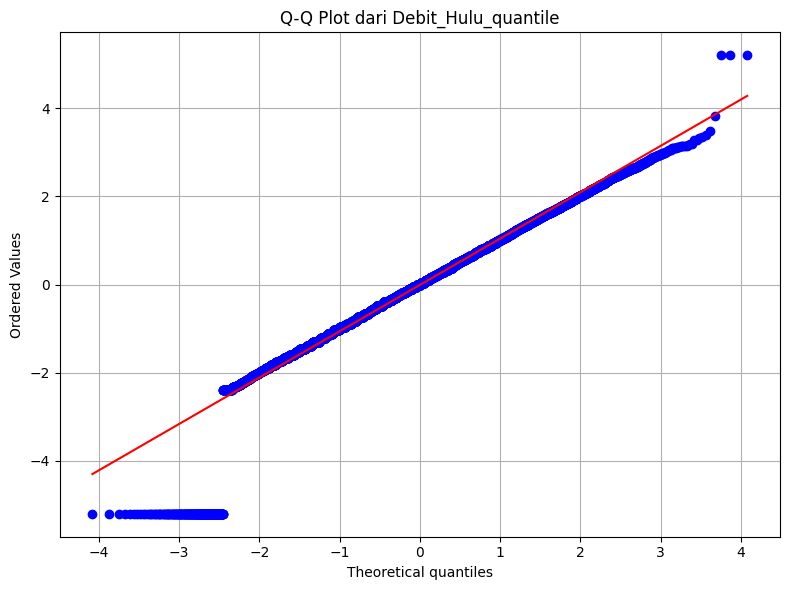

In [13]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 2. Debit_Hulu

var = 'Debit_Hulu'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [14]:
# 3. Debit_Hilir

# Transformasi Logaritmik
df['Debit_Hilir_log'] = np.log1p(df['Debit_Hilir'])

# Transformasi Winsorization
df['Debit_Hilir_winsorized'] = stats.mstats.winsorize(df['Debit_Hilir'], limits=[0.05, 0.05])
# df['Debit_Hulu_winsorized'] = stats.mstats.winsorize(df['Debit_Hulu'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['Debit_Hilir_norm'] = robust_scaler.fit_transform(df[['Debit_Hilir']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['Debit_Hilir_quantile'] = quantile_transformer.fit_transform(df[['Debit_Hilir']])


          variabel  skewness          stat  p_value           test
0  Debit_Hilir_log  5.364799  31430.583724      0.0  D’Agostino K²
                 variabel  skewness          stat  p_value           test
0         Debit_Hilir_log  5.364799  31430.583724      0.0  D’Agostino K²
1  Debit_Hilir_winsorized  2.435990  15154.173874      0.0  D’Agostino K²
                 variabel  skewness          stat  p_value           test
0         Debit_Hilir_log  5.364799  31430.583724      0.0  D’Agostino K²
1  Debit_Hilir_winsorized  2.435990  15154.173874      0.0  D’Agostino K²
2        Debit_Hilir_norm  6.687787  36650.535154      0.0  D’Agostino K²
                 variabel  skewness          stat  p_value           test
0         Debit_Hilir_log  5.364799  31430.583724      0.0  D’Agostino K²
1  Debit_Hilir_winsorized  2.435990  15154.173874      0.0  D’Agostino K²
2        Debit_Hilir_norm  6.687787  36650.535154      0.0  D’Agostino K²
3    Debit_Hilir_quantile -0.477423   2628.565664   

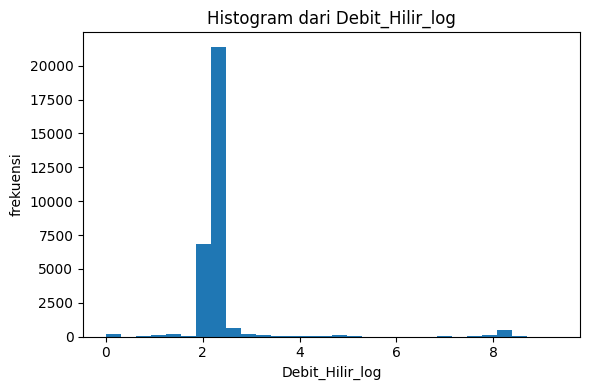

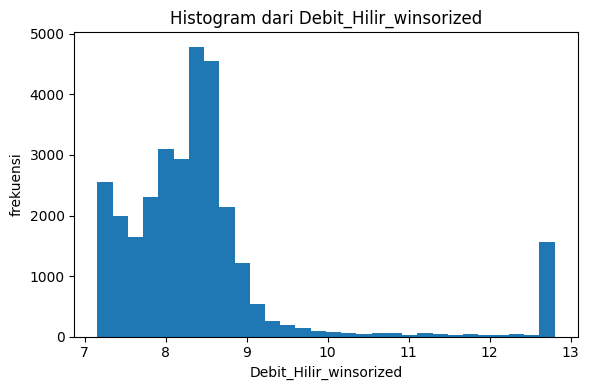

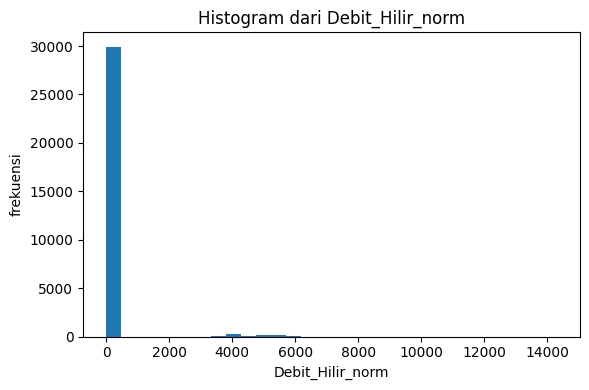

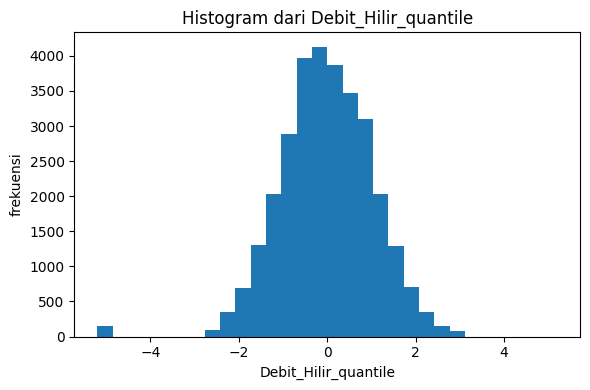

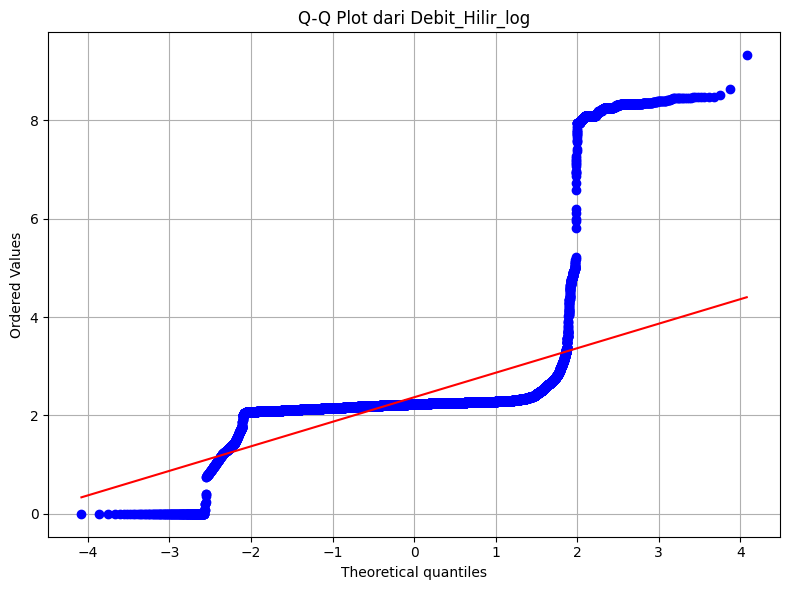

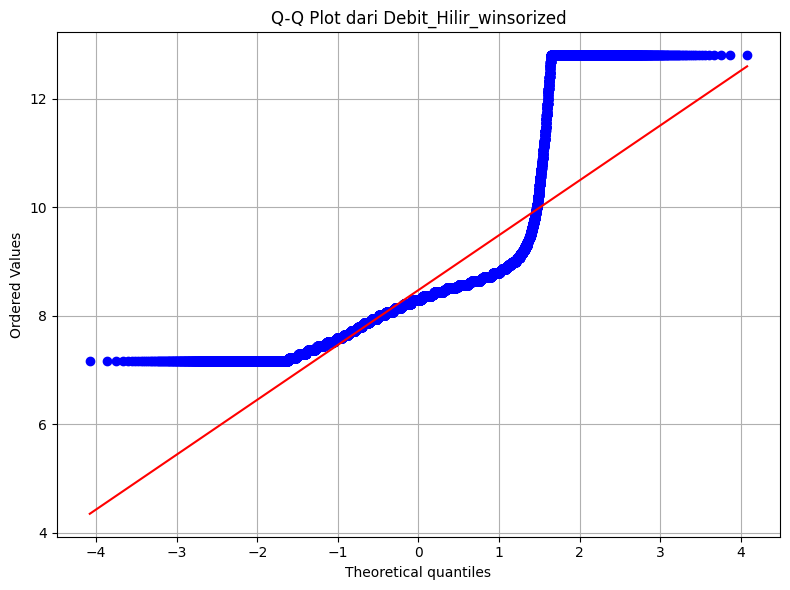

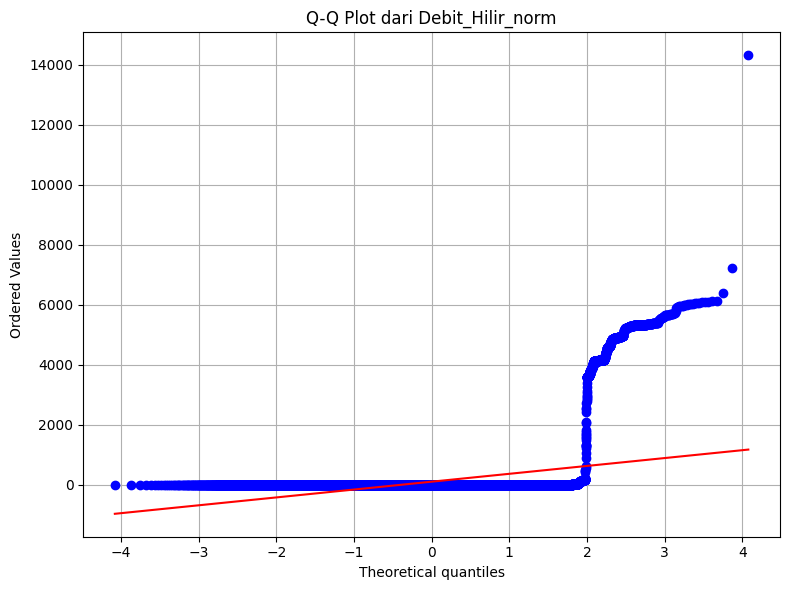

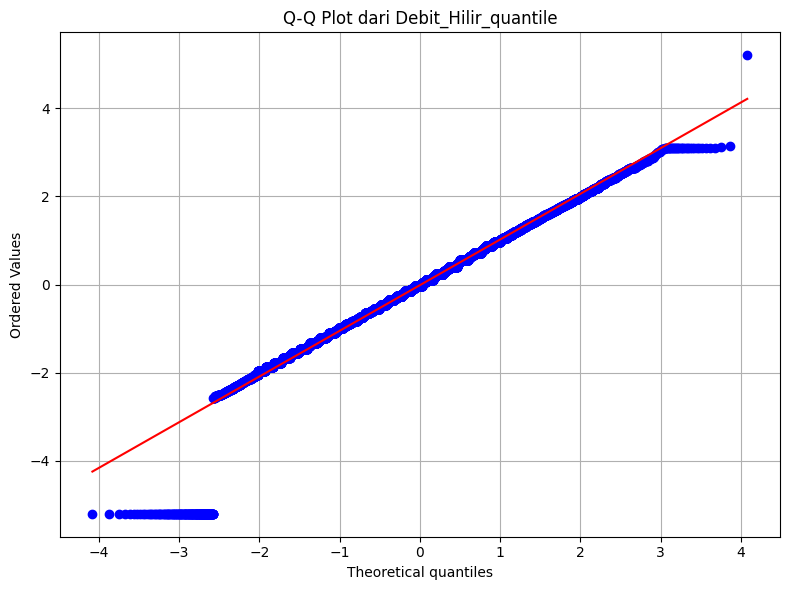

In [15]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 3. Debit_Hilir

var = 'Debit_Hilir'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [16]:
# 4. TMA_Cipalasari

# Transformasi Logaritmik
df['TMA_Cipalasari_log'] = np.log1p(df['TMA_Cipalasari'])

# Transformasi Winsorization
df['TMA_Cipalasari_winsorized'] = stats.mstats.winsorize(df['TMA_Cipalasari'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['TMA_Cipalasari_norm'] = robust_scaler.fit_transform(df[['TMA_Cipalasari']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['TMA_Cipalasari_quantile'] = quantile_transformer.fit_transform(df[['TMA_Cipalasari']])


d:\dummyML\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


             variabel  skewness        stat  p_value           test
0  TMA_Cipalasari_log  0.128894  4137.06708      0.0  D’Agostino K²
                    variabel  skewness         stat  p_value           test
0         TMA_Cipalasari_log  0.128894  4137.067080      0.0  D’Agostino K²
1  TMA_Cipalasari_winsorized  1.281019  6327.736813      0.0  D’Agostino K²
                    variabel  skewness          stat  p_value           test
0         TMA_Cipalasari_log  0.128894   4137.067080      0.0  D’Agostino K²
1  TMA_Cipalasari_winsorized  1.281019   6327.736813      0.0  D’Agostino K²
2        TMA_Cipalasari_norm  1.250574  11243.838665      0.0  D’Agostino K²
                    variabel  skewness          stat       p_value  \
0         TMA_Cipalasari_log  0.128894   4137.067080  0.000000e+00   
1  TMA_Cipalasari_winsorized  1.281019   6327.736813  0.000000e+00   
2        TMA_Cipalasari_norm  1.250574  11243.838665  0.000000e+00   
3    TMA_Cipalasari_quantile -0.031798     47.97

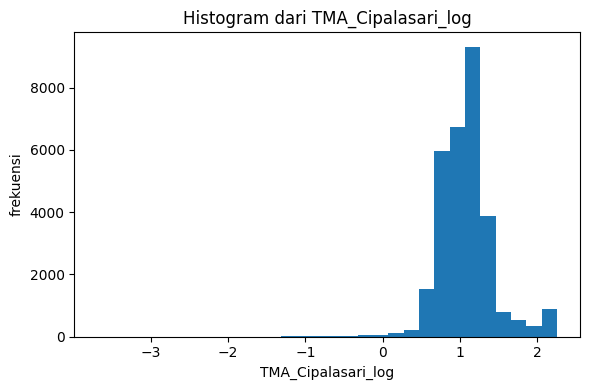

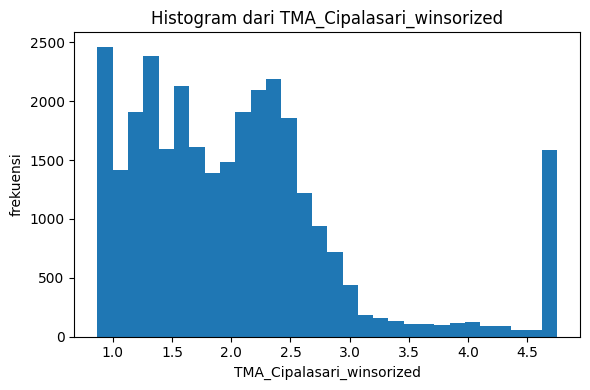

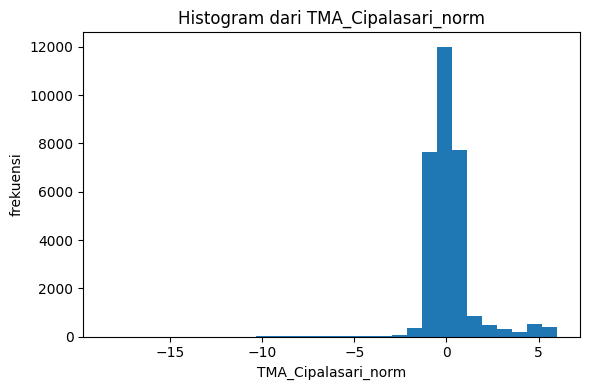

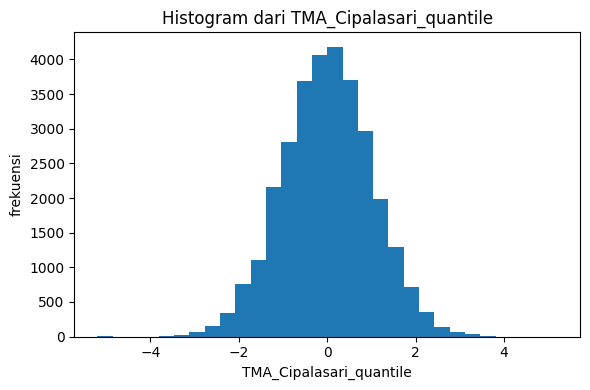

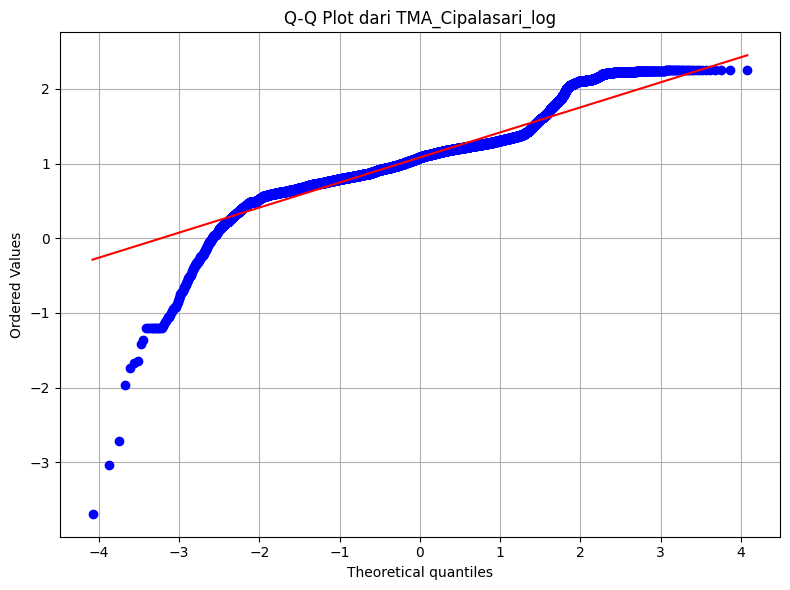

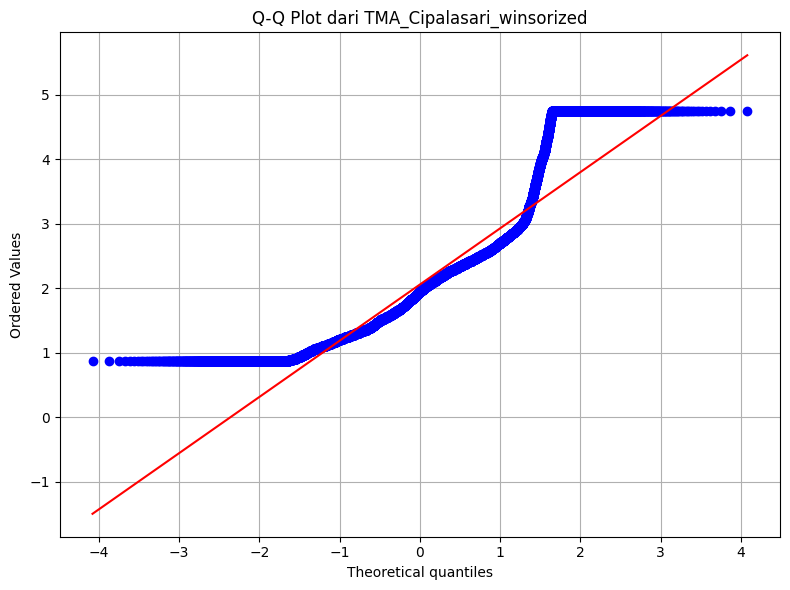

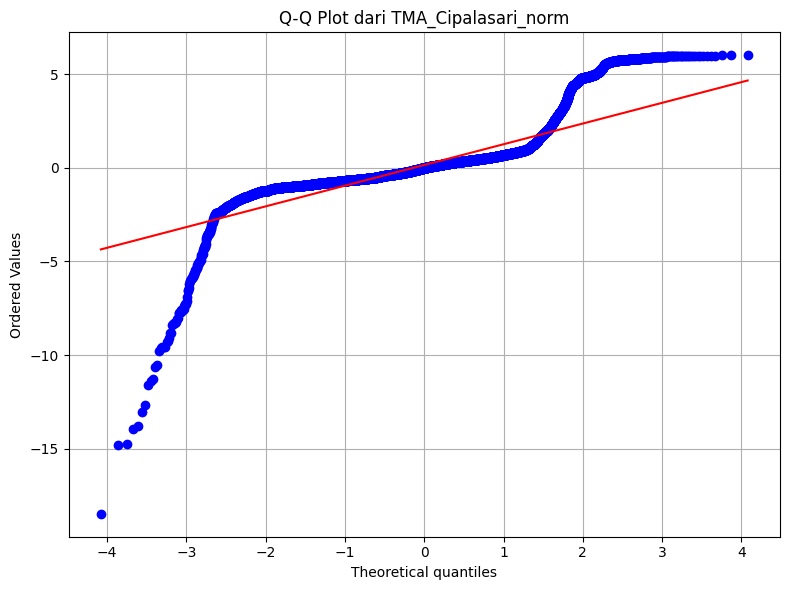

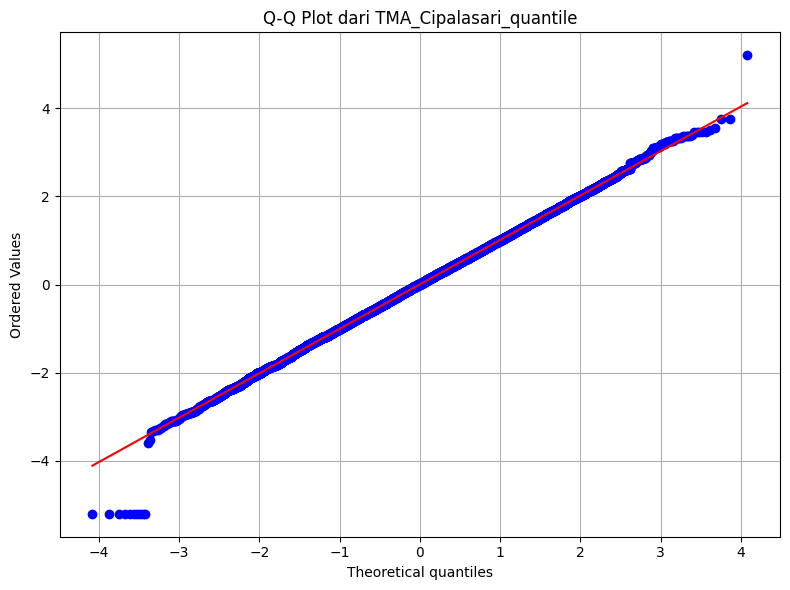

In [17]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 4. TMA_Cipalasari

var = 'TMA_Cipalasari'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [18]:
# 5. TMA_Citarum

# Transformasi Logaritmik
df['TMA_Citarum_log'] = np.log1p(df['TMA_Citarum'])

# Transformasi Winsorization
df['TMA_Citarum_winsorized'] = stats.mstats.winsorize(df['TMA_Citarum'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['TMA_Citarum_norm'] = robust_scaler.fit_transform(df[['TMA_Citarum']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['TMA_Citarum_quantile'] = quantile_transformer.fit_transform(df[['TMA_Citarum']])


          variabel  skewness         stat  p_value           test
0  TMA_Citarum_log -1.350501  7420.755998      0.0  D’Agostino K²
                 variabel  skewness         stat  p_value           test
0         TMA_Citarum_log -1.350501  7420.755998      0.0  D’Agostino K²
1  TMA_Citarum_winsorized -0.332981  5245.565072      0.0  D’Agostino K²
                 variabel  skewness         stat  p_value           test
0         TMA_Citarum_log -1.350501  7420.755998      0.0  D’Agostino K²
1  TMA_Citarum_winsorized -0.332981  5245.565072      0.0  D’Agostino K²
2        TMA_Citarum_norm -0.531134  1520.285938      0.0  D’Agostino K²
                 variabel  skewness         stat       p_value           test
0         TMA_Citarum_log -1.350501  7420.755998  0.000000e+00  D’Agostino K²
1  TMA_Citarum_winsorized -0.332981  5245.565072  0.000000e+00  D’Agostino K²
2        TMA_Citarum_norm -0.531134  1520.285938  0.000000e+00  D’Agostino K²
3    TMA_Citarum_quantile  0.028282    30.861

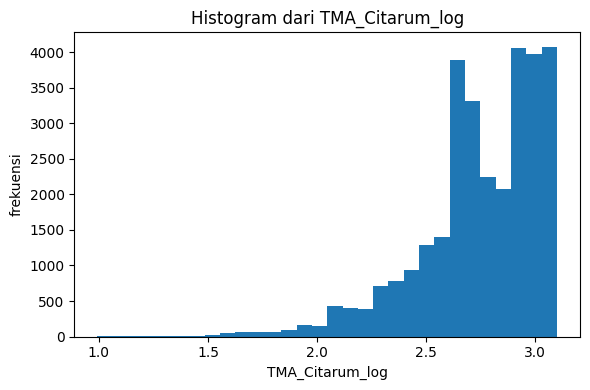

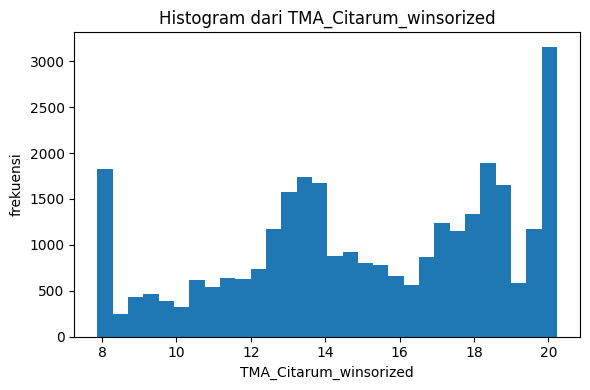

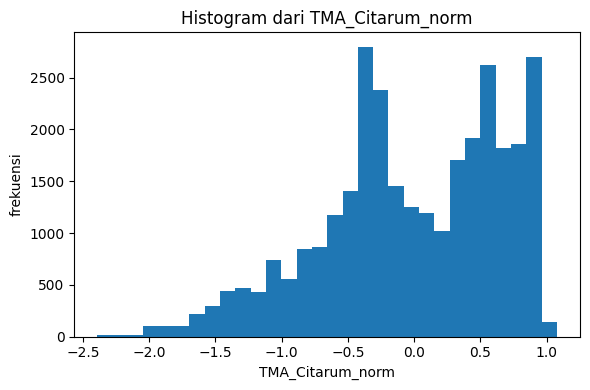

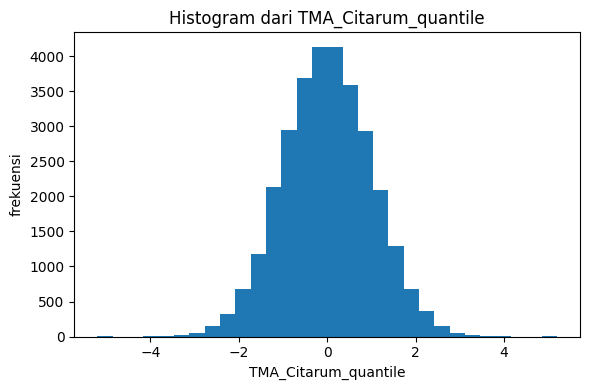

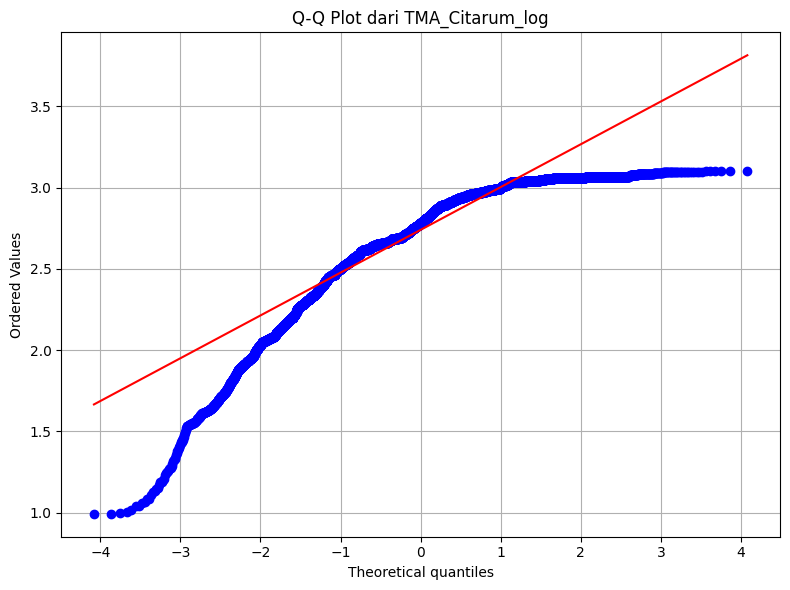

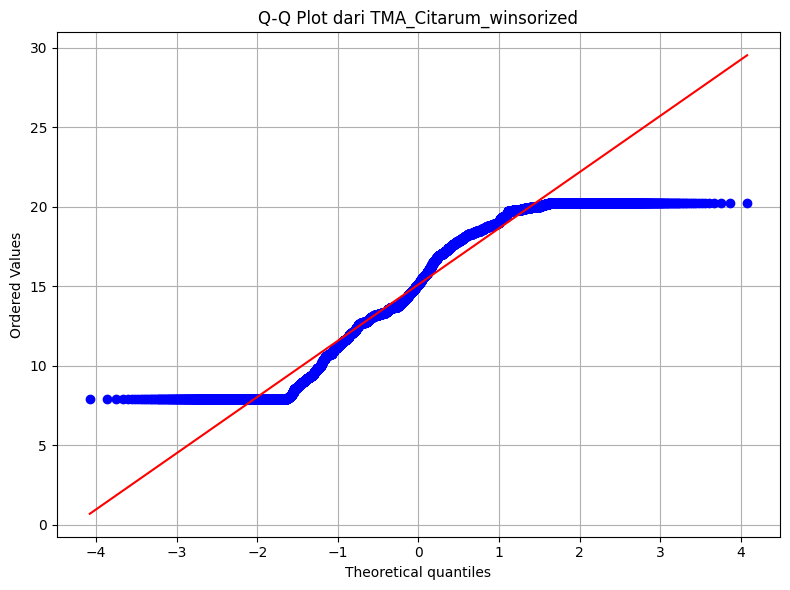

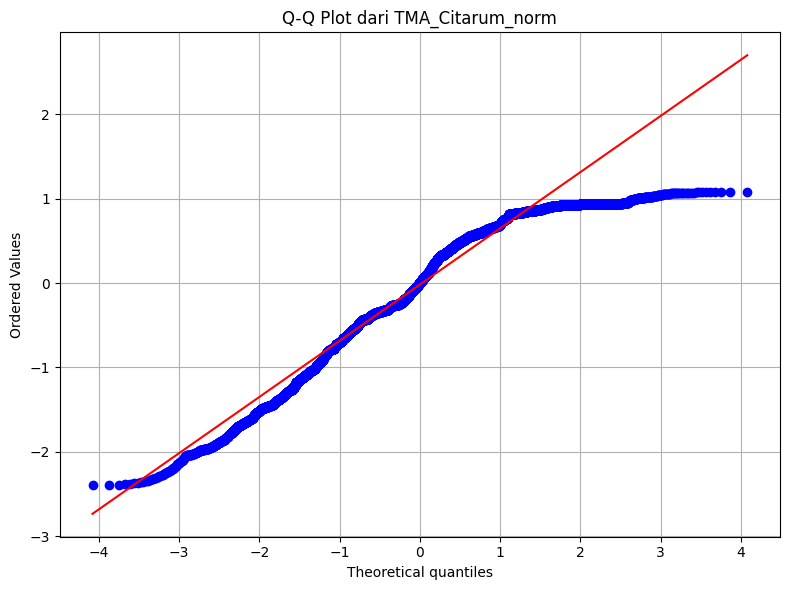

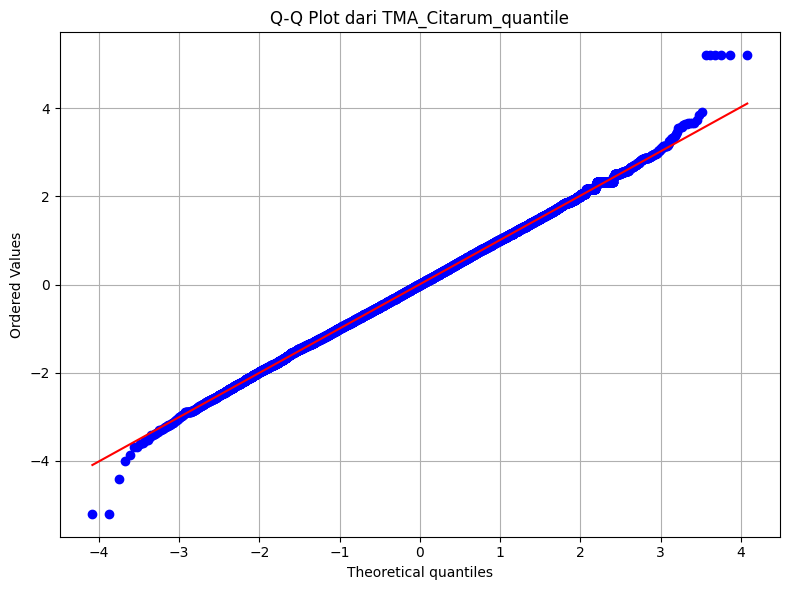

In [19]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 5. TMA_Citarum

var = 'TMA_Citarum'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [20]:
# 6. TMA_Kolam

# Transformasi Logaritmik
df['TMA_Kolam_log'] = np.log1p(df['TMA_Kolam'])

# Transformasi Winsorization
df['TMA_Kolam_winsorized'] = stats.mstats.winsorize(df['TMA_Kolam'], limits=[0.05, 0.05])

# Transformasi Robust Scaler
robust_scaler = RobustScaler()
df['TMA_Kolam_norm'] = robust_scaler.fit_transform(df[['TMA_Kolam']])

# Transformasi Quantile Transformer
quantile_transformer = QuantileTransformer(output_distribution='normal')
df['TMA_Kolam_quantile'] = quantile_transformer.fit_transform(df[['TMA_Kolam']])


        variabel  skewness           stat  p_value           test
0  TMA_Kolam_log -0.160463  140224.754928      0.0  D’Agostino K²
               variabel  skewness           stat  p_value           test
0         TMA_Kolam_log -0.160463  140224.754928      0.0  D’Agostino K²
1  TMA_Kolam_winsorized  0.193485  157224.972480      0.0  D’Agostino K²
               variabel  skewness           stat  p_value           test
0         TMA_Kolam_log -0.160463  140224.754928      0.0  D’Agostino K²
1  TMA_Kolam_winsorized  0.193485  157224.972480      0.0  D’Agostino K²
2        TMA_Kolam_norm  0.241099  197483.272822      0.0  D’Agostino K²
               variabel  skewness           stat       p_value           test
0         TMA_Kolam_log -0.160463  140224.754928  0.000000e+00  D’Agostino K²
1  TMA_Kolam_winsorized  0.193485  157224.972480  0.000000e+00  D’Agostino K²
2        TMA_Kolam_norm  0.241099  197483.272822  0.000000e+00  D’Agostino K²
3    TMA_Kolam_quantile -0.001260      74.393

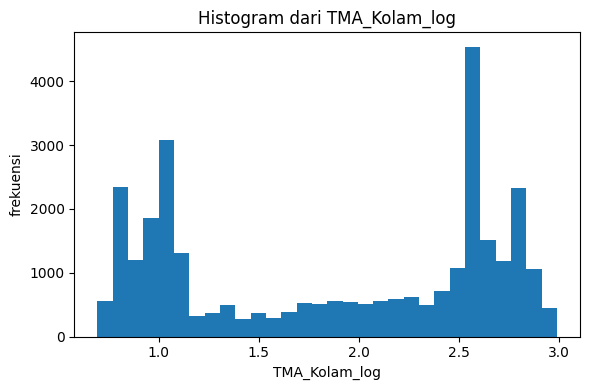

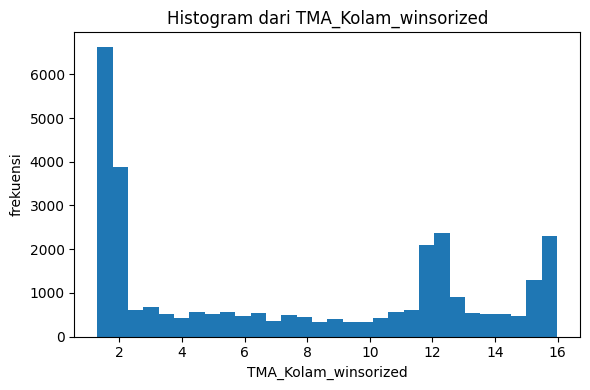

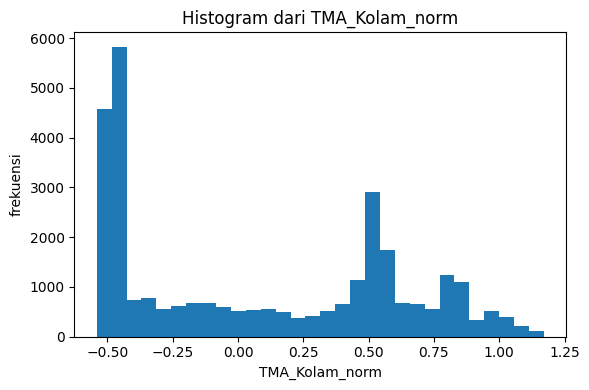

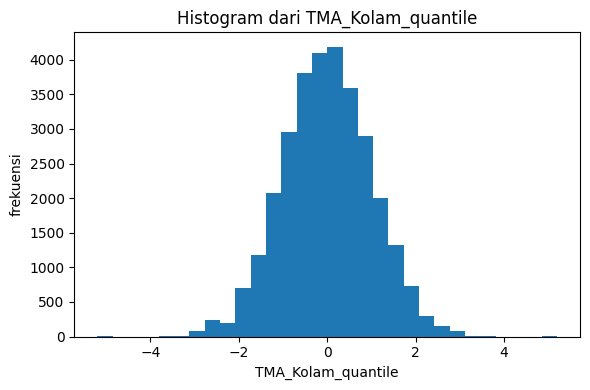

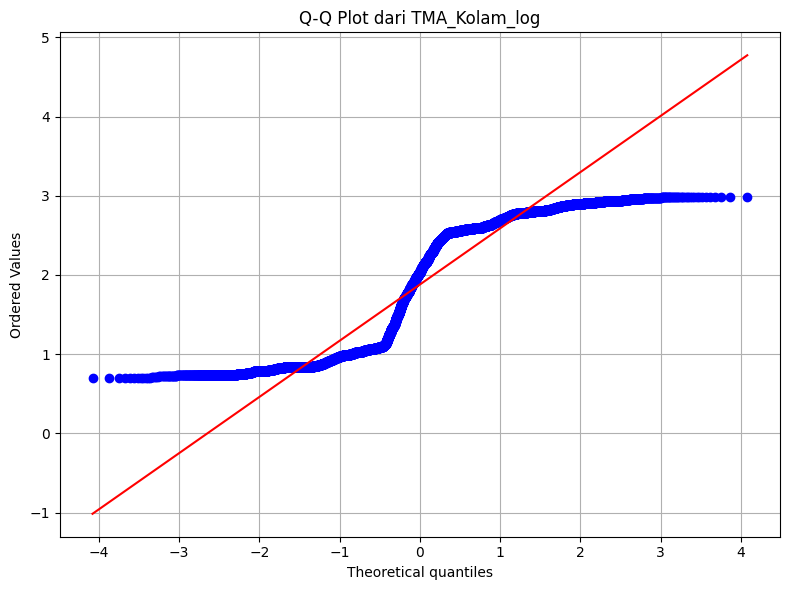

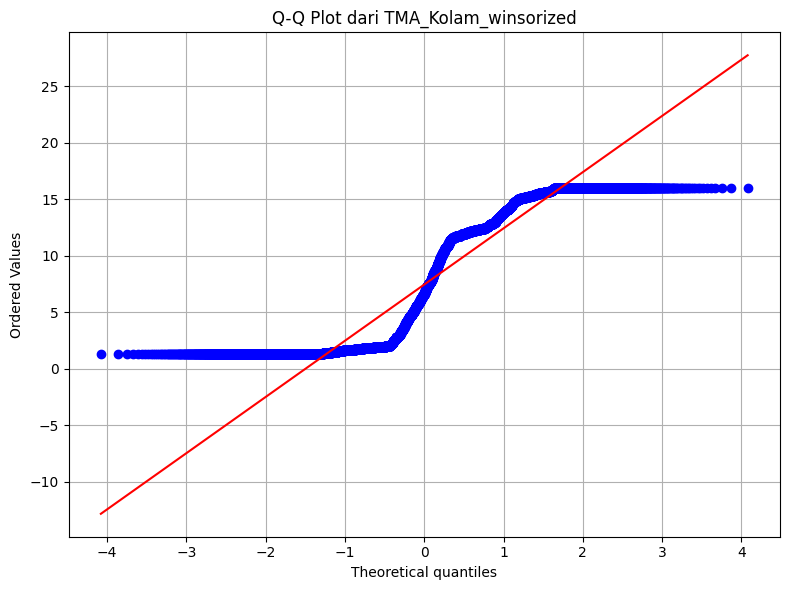

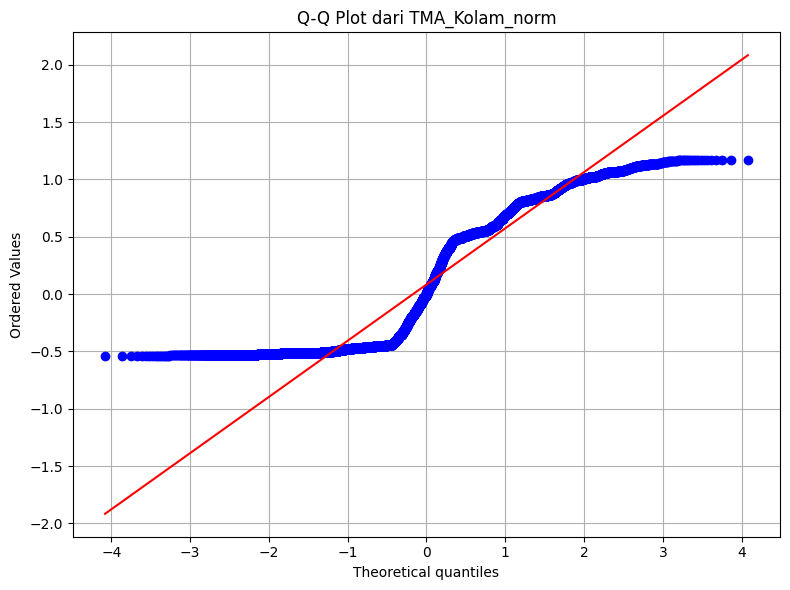

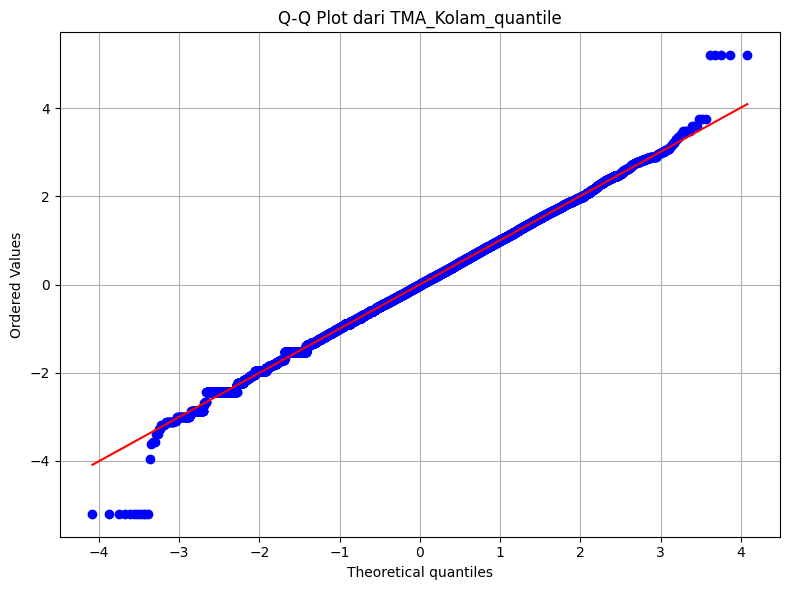

In [21]:
#Lakukan Transformasi log, winsorization, dan robust scaling pada masing masing data hidrologis
# 6. TMA_Kolam

var = 'TMA_Kolam'
variants = [
    f'{var}_log',
    f'{var}_winsorized',
    f'{var}_norm',
    f'{var}_quantile'
]

hasil = []
for col in variants:
    data = df[col].dropna()
    skew = data.skew()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro-Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    hasil.append({
        'variabel': col,
        'skewness': skew,
        'stat': stat,
        'p_value': p,
        'test': test
    })

    hasil_df = pd.DataFrame(hasil)
    print(hasil_df)

# lakukan statistical test menggunakan Q-Q plot 
for col in variants:
    data = df[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram dari {col}')
    plt.xlabel(col); plt.ylabel('frekuensi')
    plt.tight_layout()
    plt.show()

for col in variants:
    plt.figure(figsize=(8, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dari {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

## 3. Pelatihan Model

In [22]:
df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,pump,Debit_Cipalasari_log,Debit_Cipalasari_winsorized,Debit_Cipalasari_norm,...,TMA_Cipalasari_norm,TMA_Cipalasari_quantile,TMA_Citarum_log,TMA_Citarum_winsorized,TMA_Citarum_norm,TMA_Citarum_quantile,TMA_Kolam_log,TMA_Kolam_winsorized,TMA_Kolam_norm,TMA_Kolam_quantile
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,2,0.382560,2.71448,-4.684200,...,-1.203148,-1.986668,2.024164,7.8775,-1.523749,-1.995893,2.630090,12.875024,0.596880,0.868361
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,2,0.385541,2.71448,-4.678691,...,-1.207407,-2.033187,2.022823,7.8775,-1.525554,-1.998133,2.630046,12.874414,0.596822,0.868179
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,2,0.391598,2.71448,-4.667447,...,-1.216100,-2.041800,2.020080,7.8775,-1.529239,-2.002736,2.629957,12.873169,0.596703,0.867807
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,2,0.397618,2.71448,-4.656204,...,-1.224792,-2.050567,2.017330,7.8775,-1.532923,-2.007382,2.629867,12.871923,0.596583,0.867436
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,2,0.403602,2.71448,-4.644960,...,-1.233485,-2.056158,2.014572,7.8775,-1.536607,-2.012071,2.629777,12.870678,0.596464,0.867064


In [24]:
# Persiapan data untuk modeling

# 1. Buat kolom target (label) dari TMA_Kolam
def pompa_rekomendasi(tma_cm):
    if tma_cm < 3.2:
        return 0 # kondisi aman
    elif tma_cm <= 9.6:
        return 1 # Kondisi SIAGA 1
    elif tma_cm <= 14:
        return 2 # Kondisi SIAGA 2
    else:
        return 3 # Kondisi SIAGA 3

df['pump_recommendation'] = df['TMA_Kolam'].apply(pompa_rekomendasi)

df.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,pump,Debit_Cipalasari_log,Debit_Cipalasari_winsorized,Debit_Cipalasari_norm,...,TMA_Cipalasari_quantile,TMA_Citarum_log,TMA_Citarum_winsorized,TMA_Citarum_norm,TMA_Citarum_quantile,TMA_Kolam_log,TMA_Kolam_winsorized,TMA_Kolam_norm,TMA_Kolam_quantile,pump_recommendation
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,2,0.382560,2.71448,-4.684200,...,-1.986668,2.024164,7.8775,-1.523749,-1.995893,2.630090,12.875024,0.596880,0.868361,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,2,0.385541,2.71448,-4.678691,...,-2.033187,2.022823,7.8775,-1.525554,-1.998133,2.630046,12.874414,0.596822,0.868179,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,2,0.391598,2.71448,-4.667447,...,-2.041800,2.020080,7.8775,-1.529239,-2.002736,2.629957,12.873169,0.596703,0.867807,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,2,0.397618,2.71448,-4.656204,...,-2.050567,2.017330,7.8775,-1.532923,-2.007382,2.629867,12.871923,0.596583,0.867436,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,2,0.403602,2.71448,-4.644960,...,-2.056158,2.014572,7.8775,-1.536607,-2.012071,2.629777,12.870678,0.596464,0.867064,2


In [28]:
# 2. Definisikan fitur dan target dengan DATA ASLI

feature_cols = [
    'Debit_Cipalasari', 
    'Debit_Hulu', 
    'Debit_Hilir',
    'TMA_Cipalasari', 
    'TMA_Citarum', 
    'TMA_Kolam'
]

x = df[feature_cols]
y = df['pump_recommendation'] = df['pump_recommendation'].astype('category')

# 3. Split data menjadi train dan test set
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Buat preprocessing pipeline
pipelines = {
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SupportVectorMachine': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(random_state=42))
    ])
}

# 5. Latih model, prediksi dan evaluasi setiap pipeline
results = []
for name, pipeline in pipelines.items():
    print(f"Melatih model {name}...")

    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    })

print("\nHasil Evaluasi Model:")
results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
print(results_df)

Melatih model XGBoost...


d:\dummyML\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:00:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melatih model DecisionTree...
Melatih model RandomForest...
Melatih model LogisticRegression...
Melatih model SupportVectorMachine...

Hasil Evaluasi Model:
                  model  accuracy  f1_score       MAE      RMSE
1          DecisionTree  0.999783  0.999782  0.000217  0.014747
2          RandomForest  0.999565  0.999565  0.000435  0.020856
0               XGBoost  0.997934  0.997933  0.002066  0.045455
3    LogisticRegression  0.992497  0.992489  0.007503  0.086621
4  SupportVectorMachine  0.983362  0.983344  0.016746  0.130246


In [37]:
# 6. Percobaan dengan data asli untuk prediksi

print("\n" + "="*40)
print("==          PERCOBAAN PREDIKSI DENGAN DATA ASLI         ==")
print("="*40 + "\n")

# Pilih pipeline terbaik dari hasil evaluasi
best_model_name = results_df.iloc[0]['model']
best_pipeline = pipelines[best_model_name]
print(f"Model Terbaik: **{best_model_name}**\n")

# Lakukan prediksi dengan data asli
data_baru_asli = {
    'Debit_Cipalasari': [5],
    'Debit_Hilir': [8],
    'Debit_Hulu': [6],
    'TMA_Cipalasari': [2],
    'TMA_Citarum': [20],
    'TMA_Kolam': [13]  # TMA Kolam 15 cm (seharusnya masuk kategori Siaga 3)
}

data_untuk_prediksi = pd.DataFrame(data_baru_asli, columns=feature_cols)

# Lakukan prediksi dengan pipeline terbaik
prediksi = best_pipeline.predict(data_untuk_prediksi)

#Tampilkan hasil prediksi (yang mudah dibaca)
status_mapping = {
    0: 'Kondisi Aman', 
    1: 'Kondisi Siaga 1',
    2: 'Kondisi Siaga 2',
    3: 'Kondisi Siaga 3'
}
prediksi_label = status_mapping[prediksi[0]]

# rekomendasi pompa berdasarkan TMA_kolam
tma_kolam = data_untuk_prediksi['TMA_Kolam'].iloc[0]
if tma_kolam < 3.2:
    rekomendasi_pompa = "0"
elif tma_kolam <= 9.6:
    rekomendasi_pompa = "1"
elif tma_kolam <= 14:
    rekomendasi_pompa = "2"
else:
    rekomendasi_pompa = "3"

print("--- Skenario Prediksi ---")
print("Data Input (nilai asli dalam cm):")
print(data_untuk_prediksi.to_string(index=False))
print("-" * 40)
print(f"Hasil Prediksi: {prediksi_label}")
print(f"Rekomendasi Pompa: {rekomendasi_pompa}")
print("-" * 40)
print("\n")


==          PERCOBAAN PREDIKSI DENGAN DATA ASLI         ==

Model Terbaik: **DecisionTree**

--- Skenario Prediksi ---
Data Input (nilai asli dalam cm):
 Debit_Cipalasari  Debit_Hulu  Debit_Hilir  TMA_Cipalasari  TMA_Citarum  TMA_Kolam
                5           6            8               2           20         13
----------------------------------------
Hasil Prediksi: Kondisi Siaga 2
Rekomendasi Pompa: 2
----------------------------------------




In [40]:
import pickle

with open('dt_model_fix.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print("Model telah berhasil disimpan dalam berkas dt_model_fix.pkl")

Model telah berhasil disimpan dalam berkas dt_model_fix.pkl
